# SoccerNet Goal Timestamp Spotting (`r2plus1d_18`)

This notebook builds an event-detection pipeline:
1. Train a clip-level goal scorer.
2. Slide over full halves to get `P(goal)` over time.
3. Post-process with smoothing + threshold + NMS.
4. Tune for high recall with low false alarms using configurable tolerance (default `+-5s`).


In [16]:
# Cell 1: Setup and global config
import os
import json
import random
from dataclasses import dataclass
from typing import List, Tuple

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.models.video import r2plus1d_18, R2Plus1D_18_Weights
from tqdm.auto import tqdm

try:
    from SoccerNet.utils import getListGames
except Exception as e:
    raise ImportError(
        "SoccerNet package is required. Install with: pip install SoccerNet"
    ) from e

try:
    from sklearn.metrics import average_precision_score, precision_recall_fscore_support
except Exception as e:
    raise ImportError(
        "scikit-learn is required. Install with: pip install scikit-learn"
    ) from e

@dataclass
class CFG:
    # Paths
    DATA_ROOT: str = "/home/jinny/aspotting/dataset"
    CKPT_DIR: str = "/home/jinny/aspotting/checkpoints/19feb"
    OUT_DIR: str = "/home/jinny/aspotting/logs"
    BEST_DIR: str = "/home/jinny/aspotting/checkpoints/19feb/best_goal_event_r2plus1d18.pt"

    # Repro
    SEED: int = 42

    # Clip extraction
    CLIP_SEC: float = 8.0
    NUM_FRAMES: int = 16
    IMG_SIZE: int = 112

    # Training samples
    GOAL_JITTERS_TRAIN: Tuple[float, ...] = (-2.0, 0.0, 2.0)
    NEG_HARD_PER_GOAL: int = 3
    NEG_RAND_PER_GOAL: int = 4
    NEG_PER_NO_GOAL_HALF: int = 12
    MIN_NEG_FROM_GOAL_SEC: float = 12.0

    # Train
    EPOCHS: int = 8
    BATCH_SIZE: int = 8
    LR: float = 1e-4
    WEIGHT_DECAY: float = 1e-4
    NUM_WORKERS: int = 6
    PRETRAINED: bool = True
    USE_SAMPLER: bool = True

    # Sliding inference
    STRIDE_SEC: float = 1.0
    INFER_BATCH_SIZE: int = 32

    # Fast tuning controls for Cell 9
    QUICK_TUNE: bool = True
    VALID_TUNE_MAX_HALVES: int = 25
    VALID_TUNE_MAX_SECONDS: float = None   # 10 min per half
    VALID_TUNE_STRIDE_SEC: float = 2.0     # coarse for speed
    VALID_TUNE_GOAL_ONLY: bool = False

    # Event post-processing (tunable)
    TOLERANCE_SEC: float = 5.0
    SMOOTH_WINDOWS: Tuple[int, ...] = (5, 7, 9)
    THRESHOLDS: Tuple[float, ...] = tuple(np.round(np.linspace(0.45, 0.90, 12), 3))
    NMS_SEPARATIONS: Tuple[float, ...] = (60.0, 75.0, 90.0)

    # Selection objective
    TARGET_RECALL: float = 0.80

cfg = CFG()
os.makedirs(cfg.CKPT_DIR, exist_ok=True)
os.makedirs(cfg.OUT_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Data root:", cfg.DATA_ROOT)
print("Tolerance (+- sec):", cfg.TOLERANCE_SEC)
if cfg.QUICK_TUNE:
    print("QUICK_TUNE enabled: faster but less exact parameter tuning")

random.seed(cfg.SEED)
np.random.seed(cfg.SEED)
torch.manual_seed(cfg.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.SEED)


Device: cuda
Data root: /home/jinny/aspotting/dataset
Tolerance (+- sec): 5.0
QUICK_TUNE enabled: faster but less exact parameter tuning


In [2]:
# Cell 2: Load official SoccerNet splits and parse annotations
HARD_NEG_LABELS = {
    "shots on target",
    "shots off target",
    "penalty",
    "direct free-kick",
    "corner",
}

def parse_game_time(game_time: str):
    if not isinstance(game_time, str) or "-" not in game_time:
        return None, None
    a, b = game_time.split("-", 1)
    try:
        half = int(a.strip())
        mm, ss = b.strip().split(":")
        return half, int(mm) * 60 + int(ss)
    except Exception:
        return None, None

def video_duration_sec(video_path: str):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    n = cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0
    cap.release()
    if n <= 1:
        return None
    return float(n / fps)

def annotation_path(rel_game: str):
    return os.path.join(cfg.DATA_ROOT, rel_game, "Labels-v2.json")

def video_path(rel_game: str, half: int):
    return os.path.join(cfg.DATA_ROOT, rel_game, f"{half}_224p.mkv")

def load_half_metadata(split_name: str) -> List[dict]:
    rows = []
    games = getListGames(split_name)
    for rel_game in tqdm(games, desc=f"Loading {split_name} metadata"):
        ann_path = annotation_path(rel_game)
        if not os.path.exists(ann_path):
            continue
        try:
            with open(ann_path, "r") as f:
                obj = json.load(f)
        except Exception:
            continue

        annotations = obj.get("annotations", [])
        goal_times = {1: [], 2: []}
        hard_times = {1: [], 2: []}

        for ev in annotations:
            label = str(ev.get("label", "")).strip().lower()
            half, tsec = parse_game_time(ev.get("gameTime", ""))
            if half not in (1, 2) or tsec is None:
                continue
            if label == "goal":
                goal_times[half].append(float(tsec))
            if label in HARD_NEG_LABELS:
                hard_times[half].append(float(tsec))

        for half in (1, 2):
            vpath = video_path(rel_game, half)
            if not os.path.exists(vpath):
                continue
            dur = video_duration_sec(vpath)
            if dur is None:
                continue
            rows.append({
                "split": split_name,
                "rel_game": rel_game,
                "half": half,
                "video_path": vpath,
                "duration_sec": dur,
                "goal_times": sorted(goal_times[half]),
                "hard_times": sorted(hard_times[half]),
            })
    return rows

train_halves = load_half_metadata("train")
valid_halves = load_half_metadata("valid")
print("Train halves:", len(train_halves))
print("Valid halves:", len(valid_halves))


Loading valid metadata: 100%|██████████| 100/100 [00:00<00:00, 118.90it/s]

Train halves: 600
Valid halves: 200


In [3]:
# Cell 3: Build clip-level train/valid samples

def far_from_times(t: float, times: List[float], min_gap: float) -> bool:
    return all(abs(t - x) >= min_gap for x in times)

def sample_random_times(duration: float, n: int, forbidden: List[float], min_gap: float, clip_sec: float) -> List[float]:
    if duration <= clip_sec + 1:
        return []
    lo = clip_sec / 2
    hi = duration - clip_sec / 2
    if hi <= lo:
        return []

    out = []
    tries = 0
    max_tries = 8000
    forbidden_local = list(forbidden)

    while len(out) < n and tries < max_tries:
        tries += 1
        t = random.uniform(lo, hi)
        if far_from_times(t, forbidden_local, min_gap):
            out.append(float(t))
            forbidden_local.append(float(t))
    return out

def build_clip_manifest(halves: List[dict], split_name: str) -> pd.DataFrame:
    rows = []

    for h in tqdm(halves, desc=f"Building {split_name} clips"):
        dur = h["duration_sec"]
        goals = h["goal_times"]
        hard = h["hard_times"]

        # Positives
        jitters = cfg.GOAL_JITTERS_TRAIN if split_name == "train" else (0.0,)
        for g in goals:
            for j in jitters:
                c = float(np.clip(g + j, cfg.CLIP_SEC / 2, dur - cfg.CLIP_SEC / 2))
                rows.append({
                    "split": split_name,
                    "rel_game": h["rel_game"],
                    "half": h["half"],
                    "video_path": h["video_path"],
                    "center_sec": c,
                    "label": 1,
                })

        # Hard negatives near non-goal highlight-like events
        hard_candidates = [t for t in hard if far_from_times(t, goals, cfg.MIN_NEG_FROM_GOAL_SEC)]
        n_goal = max(1, len(goals))
        n_hard = min(len(hard_candidates), cfg.NEG_HARD_PER_GOAL * n_goal)
        if n_hard > 0:
            chosen = random.sample(hard_candidates, k=n_hard)
            for t in chosen:
                c = float(np.clip(t, cfg.CLIP_SEC / 2, dur - cfg.CLIP_SEC / 2))
                rows.append({
                    "split": split_name,
                    "rel_game": h["rel_game"],
                    "half": h["half"],
                    "video_path": h["video_path"],
                    "center_sec": c,
                    "label": 0,
                })

        # Random background negatives
        n_rand = cfg.NEG_RAND_PER_GOAL * len(goals) if len(goals) > 0 else cfg.NEG_PER_NO_GOAL_HALF
        forbidden = goals + hard_candidates
        sampled = sample_random_times(
            duration=dur,
            n=n_rand,
            forbidden=forbidden,
            min_gap=cfg.MIN_NEG_FROM_GOAL_SEC,
            clip_sec=cfg.CLIP_SEC,
        )
        for t in sampled:
            rows.append({
                "split": split_name,
                "rel_game": h["rel_game"],
                "half": h["half"],
                "video_path": h["video_path"],
                "center_sec": float(t),
                "label": 0,
            })

    df = pd.DataFrame(rows).drop_duplicates()
    return df

train_df = build_clip_manifest(train_halves, "train")
valid_df = build_clip_manifest(valid_halves, "valid")

print("Train samples:", len(train_df), "| Positives:", int(train_df.label.sum()))
print("Valid samples:", len(valid_df), "| Positives:", int(valid_df.label.sum()))

train_csv = os.path.join(cfg.OUT_DIR, "goal_train_clips.csv")
valid_csv = os.path.join(cfg.OUT_DIR, "goal_valid_clips.csv")
train_df.to_csv(train_csv, index=False)
valid_df.to_csv(valid_csv, index=False)
print("Saved:", train_csv)
print("Saved:", valid_csv)


Building valid clips: 100%|██████████| 200/200 [00:00<00:00, 28797.14it/s]

Train samples: 11580 | Positives: 2911
Valid samples: 3474 | Positives: 361
Saved: /home/jinny/aspotting/logs/goal_train_clips.csv
Saved: /home/jinny/aspotting/logs/goal_valid_clips.csv


In [4]:
# Cell 4: Dataset and dataloaders

def extract_clip_cv2(video_path: str, center_sec: float, clip_sec: float, num_frames: int, size: int) -> torch.Tensor:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    start_sec = max(0.0, float(center_sec) - clip_sec / 2)
    start_frame = int(start_sec * fps)
    step = max(1, int((clip_sec * fps) / num_frames))

    frames = []
    for i in range(num_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame + i * step)
        ok, frame = cap.read()
        if not ok:
            break
        frame = cv2.resize(frame, (size, size), interpolation=cv2.INTER_AREA)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()

    if not frames:
        raise RuntimeError(f"No frames read: {video_path}")

    while len(frames) < num_frames:
        frames.append(frames[-1].copy())

    arr = np.stack(frames, axis=0).astype(np.float32) / 255.0
    arr = np.transpose(arr, (3, 0, 1, 2))
    return torch.from_numpy(arr)

class GoalClipDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        x = extract_clip_cv2(
            r.video_path,
            r.center_sec,
            clip_sec=cfg.CLIP_SEC,
            num_frames=cfg.NUM_FRAMES,
            size=cfg.IMG_SIZE,
        )
        y = torch.tensor(float(r.label), dtype=torch.float32)
        return x, y

train_ds = GoalClipDataset(train_df)
valid_ds = GoalClipDataset(valid_df)

if cfg.USE_SAMPLER:
    labels = train_df["label"].values
    class_counts = np.bincount(labels.astype(int), minlength=2)
    class_weights = np.array([1.0 / max(class_counts[0], 1), 1.0 / max(class_counts[1], 1)])
    sample_weights = class_weights[labels.astype(int)]
    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights).double(),
        num_samples=len(sample_weights),
        replacement=True,
    )
    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.BATCH_SIZE,
        sampler=sampler,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=True,
    )
else:
    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.BATCH_SIZE,
        shuffle=True,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=True,
    )

valid_loader = DataLoader(
    valid_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
)

print("Train batches:", len(train_loader), "Valid batches:", len(valid_loader))


Train batches: 1448 Valid batches: 435


In [20]:
# Cell 5: Model, loss, optimizer, and train loop

weights = R2Plus1D_18_Weights.DEFAULT if cfg.PRETRAINED else None
model = r2plus1d_18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

n_pos = max(float(train_df.label.sum()), 1.0)
n_neg = max(float((train_df.label == 0).sum()), 1.0)
pos_weight = torch.tensor([n_neg / n_pos], device=device)
print("pos_weight:", float(pos_weight.item()))

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

best_path = os.path.join(cfg.CKPT_DIR, "best_goal_event_r2plus1d18.pt")
latest_path = os.path.join(cfg.CKPT_DIR, "latest_goal_event_r2plus1d18.pt")


def run_eval_clip_metrics(model, loader, threshold=0.5):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            logits = model(x).squeeze(1)
            probs = torch.sigmoid(logits)
            ys.append(y.detach().cpu().numpy())
            ps.append(probs.detach().cpu().numpy())

    y_true = np.concatenate(ys)
    y_prob = np.concatenate(ps)
    y_hat = (y_prob >= threshold).astype(np.int32)

    p, r, f1, _ = precision_recall_fscore_support(
        y_true.astype(int), y_hat, average="binary", zero_division=0
    )
    auprc = average_precision_score(y_true.astype(int), y_prob)
    return {"precision": float(p), "recall": float(r), "f1": float(f1), "auprc": float(auprc)}


# Fast event monitor during training (subset of valid halves)
EVENT_MONITOR_ENABLE = True
EVENT_MONITOR_EVERY_EPOCHS = 1
EVENT_MONITOR_MAX_HALVES = 10
EVENT_MONITOR_MAX_SECONDS = 900.0   # first 15 minutes
EVENT_MONITOR_STRIDE_SEC = 4.0
EVENT_MONITOR_THRESHOLD = 0.40
EVENT_MONITOR_SMOOTH_K = 5
EVENT_MONITOR_NMS_SEP = 40.0
EVENT_MONITOR_BATCH_SIZE = 24
EVENT_MONITOR_GOAL_ONLY = True


def _extract_clip_from_open_cap(cap, fps: float, center_sec: float, clip_sec: float, num_frames: int, size: int):
    start_sec = max(0.0, float(center_sec) - clip_sec / 2.0)
    start_frame = int(start_sec * fps)
    step = max(1, int((clip_sec * fps) / num_frames))

    frames = []
    for i in range(num_frames):
        frame_idx = start_frame + i * step
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ok, frame = cap.read()
        if not ok:
            break
        frame = cv2.resize(frame, (size, size), interpolation=cv2.INTER_AREA)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    if len(frames) == 0:
        return None

    while len(frames) < num_frames:
        frames.append(frames[-1].copy())

    arr = np.stack(frames, axis=0).astype(np.float32) / 255.0
    arr = np.transpose(arr, (3, 0, 1, 2))
    return torch.from_numpy(arr)


def _score_half_fast(model, video_path: str, stride_sec: float, clip_sec: float, num_frames: int, size: int, batch_size: int, max_seconds=None):
    dur = video_duration_sec(video_path)
    if dur is None:
        return np.array([]), np.array([])

    if max_seconds is not None:
        dur = min(float(dur), float(max_seconds))

    t0 = clip_sec / 2.0
    t1 = max(t0, dur - clip_sec / 2.0)
    centers = np.arange(t0, t1 + 1e-6, stride_sec, dtype=np.float32)
    if len(centers) == 0:
        return np.array([]), np.array([])

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return np.array([]), np.array([])
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0

    probs = []
    batch = []

    with torch.no_grad():
        for c in centers:
            clip = _extract_clip_from_open_cap(cap, fps, float(c), clip_sec, num_frames, size)
            if clip is None:
                probs.append(0.0)
                continue

            batch.append(clip)
            if len(batch) >= batch_size:
                x = torch.stack(batch, dim=0).to(device, non_blocking=True)
                p = torch.sigmoid(model(x).squeeze(1)).detach().cpu().numpy().tolist()
                probs.extend(p)
                batch = []

        if len(batch) > 0:
            x = torch.stack(batch, dim=0).to(device, non_blocking=True)
            p = torch.sigmoid(model(x).squeeze(1)).detach().cpu().numpy().tolist()
            probs.extend(p)

    cap.release()

    if len(probs) != len(centers):
        m = min(len(probs), len(centers))
        centers = centers[:m]
        probs = probs[:m]

    return centers, np.array(probs, dtype=np.float32)


def _moving_average(x: np.ndarray, k: int) -> np.ndarray:
    if k <= 1 or len(x) == 0:
        return x.copy()
    pad = k // 2
    xpad = np.pad(x, (pad, pad), mode="edge")
    kernel = np.ones(k, dtype=np.float32) / float(k)
    return np.convolve(xpad, kernel, mode="valid")


def _nms_1d(times: np.ndarray, scores: np.ndarray, min_sep_sec: float):
    if len(times) == 0:
        return np.array([]), np.array([])
    order = np.argsort(scores)[::-1]
    keep = []
    suppressed = np.zeros(len(times), dtype=bool)

    for i in order:
        if suppressed[i]:
            continue
        keep.append(i)
        suppressed |= (np.abs(times - times[i]) < min_sep_sec)
        suppressed[i] = False

    keep = np.array(keep, dtype=int)
    s = np.argsort(times[keep])
    return times[keep][s], scores[keep][s]


def _detect_events(centers: np.ndarray, probs: np.ndarray, threshold: float, smooth_k: int, nms_sep_sec: float):
    if len(centers) == 0:
        return np.array([]), np.array([])

    sm = _moving_average(probs, smooth_k)
    peak_idx = []
    for i in range(len(sm)):
        left = sm[i - 1] if i - 1 >= 0 else -1.0
        right = sm[i + 1] if i + 1 < len(sm) else -1.0
        if sm[i] >= threshold and sm[i] >= left and sm[i] >= right:
            peak_idx.append(i)

    if len(peak_idx) == 0:
        return np.array([]), np.array([])

    cand_t = centers[np.array(peak_idx)]
    cand_s = sm[np.array(peak_idx)]
    return _nms_1d(cand_t, cand_s, min_sep_sec=nms_sep_sec)


def _match_events(pred_times, pred_scores, gt_times, tol_sec: float):
    if len(pred_times) == 0:
        return 0, 0, len(gt_times)

    pred_times = np.array(pred_times, dtype=np.float32)
    pred_scores = np.array(pred_scores, dtype=np.float32)
    gt_times = np.array(gt_times, dtype=np.float32)

    used_gt = np.zeros(len(gt_times), dtype=bool)
    order = np.argsort(pred_scores)[::-1]

    tp = 0
    fp = 0
    for i in order:
        if len(gt_times) == 0:
            fp += 1
            continue
        d = np.abs(gt_times - pred_times[i])
        j = int(np.argmin(d))
        if d[j] <= cfg.TOLERANCE_SEC and not used_gt[j]:
            tp += 1
            used_gt[j] = True
        else:
            fp += 1

    fn = int((~used_gt).sum())
    return tp, fp, fn


def run_event_monitor(model):
    if EVENT_MONITOR_GOAL_ONLY:
        pool = [h for h in valid_halves if len(h.get("goal_times", [])) > 0]
        if len(pool) == 0:
            pool = list(valid_halves)
    else:
        pool = list(valid_halves)

    rng = random.Random(cfg.SEED)
    if EVENT_MONITOR_MAX_HALVES is not None and EVENT_MONITOR_MAX_HALVES < len(pool):
        halves = rng.sample(pool, k=EVENT_MONITOR_MAX_HALVES)
    else:
        halves = pool

    tp = fp = fn = 0
    for h in halves:
        centers, probs = _score_half_fast(
            model,
            h["video_path"],
            stride_sec=EVENT_MONITOR_STRIDE_SEC,
            clip_sec=cfg.CLIP_SEC,
            num_frames=cfg.NUM_FRAMES,
            size=cfg.IMG_SIZE,
            batch_size=EVENT_MONITOR_BATCH_SIZE,
            max_seconds=EVENT_MONITOR_MAX_SECONDS,
        )

        pred_t, pred_s = _detect_events(
            centers,
            probs,
            threshold=EVENT_MONITOR_THRESHOLD,
            smooth_k=EVENT_MONITOR_SMOOTH_K,
            nms_sep_sec=EVENT_MONITOR_NMS_SEP,
        )

        if EVENT_MONITOR_MAX_SECONDS is None:
            gt = h["goal_times"]
        else:
            gt = [t for t in h["goal_times"] if t <= EVENT_MONITOR_MAX_SECONDS]

        tpi, fpi, fni = _match_events(pred_t.tolist(), pred_s.tolist(), gt, tol_sec=cfg.TOLERANCE_SEC)
        tp += tpi
        fp += fpi
        fn += fni

    recall = tp / max(tp + fn, 1)
    fp_per_half = fp / max(len(halves), 1)
    return {
        "recall": float(recall),
        "fp_per_half": float(fp_per_half),
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "n_halves": int(len(halves)),
    }


print(
    f"Event monitor config: halves={EVENT_MONITOR_MAX_HALVES}, "
    f"sec={EVENT_MONITOR_MAX_SECONDS}, stride={EVENT_MONITOR_STRIDE_SEC}, "
    f"thr={EVENT_MONITOR_THRESHOLD}, smooth={EVENT_MONITOR_SMOOTH_K}, nms={EVENT_MONITOR_NMS_SEP}"
)

best_val_auprc = -1.0
for epoch in range(1, cfg.EPOCHS + 1):
    model.train()
    running = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{cfg.EPOCHS} [train]")
    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            logits = model(x).squeeze(1)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running += loss.item()
        pbar.set_postfix(train_loss=running / max(1, pbar.n))

    val_m = run_eval_clip_metrics(model, valid_loader, threshold=0.5)
    msg = (
        f"Epoch {epoch}: val_AUPRC={val_m['auprc']:.4f} "
        f"val_P/R/F1={val_m['precision']:.3f}/{val_m['recall']:.3f}/{val_m['f1']:.3f}"
    )

    if EVENT_MONITOR_ENABLE and (epoch % EVENT_MONITOR_EVERY_EPOCHS == 0):
        event_m = run_event_monitor(model)
        msg += (
            f" | event_recall={event_m['recall']:.3f} "
            f"event_fp_per_half={event_m['fp_per_half']:.2f} "
            f"(tp/fp/fn={event_m['tp']}/{event_m['fp']}/{event_m['fn']}, halves={event_m['n_halves']})"
        )

    print(msg)

    ckpt = {"epoch": epoch, "model": model.state_dict(), "cfg": cfg.__dict__}
    torch.save(ckpt, latest_path)

    if val_m["auprc"] > best_val_auprc:
        best_val_auprc = val_m["auprc"]
        torch.save(ckpt, best_path)
        print("Saved BEST:", best_path)

print("Training complete.")


pos_weight: 2.9780144691467285
Event monitor config: halves=10, sec=900.0, stride=4.0, thr=0.4, smooth=5, nms=40.0


Epoch 1/8 [train]: 100%|██████████| 1448/1448 [19:40<00:00,  1.23it/s, train_loss=0.502]


Epoch 1: val_AUPRC=0.6341 val_P/R/F1=0.403/0.928/0.562 | event_recall=0.429 event_fp_per_half=2.00 (tp/fp/fn=3/20/4, halves=10)
Saved BEST: /home/jinny/aspotting/checkpoints/19feb/best_goal_event_r2plus1d18.pt


Epoch 2/8 [train]: 100%|██████████| 1448/1448 [19:49<00:00,  1.22it/s, train_loss=0.306]


Epoch 2: val_AUPRC=0.6581 val_P/R/F1=0.418/0.920/0.575 | event_recall=0.429 event_fp_per_half=1.90 (tp/fp/fn=3/19/4, halves=10)
Saved BEST: /home/jinny/aspotting/checkpoints/19feb/best_goal_event_r2plus1d18.pt


...

Epoch 6: val_AUPRC=0.6727 val_P/R/F1=0.520/0.828/0.639 | event_recall=0.429 event_fp_per_half=0.20 (tp/fp/fn=3/2/4, halves=10)


Epoch 7/8 [train]: 100%|██████████| 1448/1448 [18:56<00:00,  1.27it/s, train_loss=0.0801]


Epoch 7: val_AUPRC=0.6688 val_P/R/F1=0.555/0.795/0.654 | event_recall=0.429 event_fp_per_half=0.30 (tp/fp/fn=3/3/4, halves=10)


Epoch 8/8 [train]: 100%|██████████| 1448/1448 [18:55<00:00,  1.27it/s, train_loss=0.0716]


Epoch 8: val_AUPRC=0.6474 val_P/R/F1=0.447/0.895/0.596 | event_recall=0.571 event_fp_per_half=1.80 (tp/fp/fn=4/18/3, halves=10)
Training complete.


In [7]:
# Cell 6: Load best checkpoint
weights = R2Plus1D_18_Weights.DEFAULT if cfg.PRETRAINED else None
model = r2plus1d_18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)
best_path = os.path.join(cfg.CKPT_DIR, "best_goal_event_r2plus1d18.pt")
ckpt = torch.load(best_path, map_location=device, weights_only=False)  # trusted local checkpoint
model.load_state_dict(ckpt["model"])
model.to(device)
model.eval()
print("Loaded best checkpoint from epoch", ckpt.get("epoch"))


Loaded best checkpoint from epoch 5


In [8]:
# Cell 7: Sliding-window scoring and post-processing

def _extract_clip_from_open_cap(cap, fps: float, center_sec: float, clip_sec: float, num_frames: int, size: int):
    start_sec = max(0.0, float(center_sec) - clip_sec / 2.0)
    start_frame = int(start_sec * fps)
    step = max(1, int((clip_sec * fps) / num_frames))

    frames = []
    for i in range(num_frames):
        frame_idx = start_frame + i * step
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ok, frame = cap.read()
        if not ok:
            break
        frame = cv2.resize(frame, (size, size), interpolation=cv2.INTER_AREA)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    if len(frames) == 0:
        return None

    while len(frames) < num_frames:
        frames.append(frames[-1].copy())

    arr = np.stack(frames, axis=0).astype(np.float32) / 255.0
    arr = np.transpose(arr, (3, 0, 1, 2))
    return torch.from_numpy(arr)


def score_half(
    model,
    video_path: str,
    stride_sec: float,
    clip_sec: float,
    num_frames: int,
    size: int,
    batch_size: int = 24,
    max_seconds: float = None,
):
    dur = video_duration_sec(video_path)
    if dur is None:
        return np.array([]), np.array([])

    if max_seconds is not None:
        dur = min(float(dur), float(max_seconds))

    t0 = clip_sec / 2.0
    t1 = max(t0, dur - clip_sec / 2.0)
    centers = np.arange(t0, t1 + 1e-6, stride_sec, dtype=np.float32)
    if len(centers) == 0:
        return np.array([]), np.array([])

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return np.array([]), np.array([])
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0

    probs = []
    batch = []

    with torch.no_grad():
        for c in centers:
            clip = _extract_clip_from_open_cap(cap, fps, float(c), clip_sec, num_frames, size)
            if clip is None:
                probs.append(0.0)
                continue

            batch.append(clip)
            if len(batch) >= batch_size:
                x = torch.stack(batch, dim=0).to(device, non_blocking=True)
                p = torch.sigmoid(model(x).squeeze(1)).detach().cpu().numpy().tolist()
                probs.extend(p)
                batch = []

        if len(batch) > 0:
            x = torch.stack(batch, dim=0).to(device, non_blocking=True)
            p = torch.sigmoid(model(x).squeeze(1)).detach().cpu().numpy().tolist()
            probs.extend(p)

    cap.release()

    # Guard for rare decode mismatches
    if len(probs) != len(centers):
        m = min(len(probs), len(centers))
        centers = centers[:m]
        probs = probs[:m]

    return centers, np.array(probs, dtype=np.float32)


def moving_average(x: np.ndarray, k: int) -> np.ndarray:
    if k <= 1 or len(x) == 0:
        return x.copy()
    k = int(k)
    pad = k // 2
    xpad = np.pad(x, (pad, pad), mode="edge")
    kernel = np.ones(k, dtype=np.float32) / float(k)
    return np.convolve(xpad, kernel, mode="valid")


def nms_1d(times: np.ndarray, scores: np.ndarray, min_sep_sec: float):
    if len(times) == 0:
        return np.array([]), np.array([])
    order = np.argsort(scores)[::-1]
    keep = []
    suppressed = np.zeros(len(times), dtype=bool)

    for i in order:
        if suppressed[i]:
            continue
        keep.append(i)
        suppressed |= (np.abs(times - times[i]) < min_sep_sec)
        suppressed[i] = False

    keep = np.array(keep, dtype=int)
    s = np.argsort(times[keep])
    return times[keep][s], scores[keep][s]


def detect_goal_events(centers: np.ndarray, probs: np.ndarray, threshold: float, smooth_k: int, nms_sep_sec: float):
    if len(centers) == 0:
        return np.array([]), np.array([]), np.array([])

    sm = moving_average(probs, smooth_k)

    peak_idx = []
    for i in range(len(sm)):
        left = sm[i - 1] if i - 1 >= 0 else -1.0
        right = sm[i + 1] if i + 1 < len(sm) else -1.0
        if sm[i] >= threshold and sm[i] >= left and sm[i] >= right:
            peak_idx.append(i)

    if len(peak_idx) == 0:
        return sm, np.array([]), np.array([])

    cand_times = centers[np.array(peak_idx)]
    cand_scores = sm[np.array(peak_idx)]
    final_times, final_scores = nms_1d(cand_times, cand_scores, min_sep_sec=nms_sep_sec)
    return sm, final_times, final_scores


In [9]:
# Cell 8: Event-level matching and metrics

def match_events(pred_times: List[float], pred_scores: List[float], gt_times: List[float], tol_sec: float):
    if len(pred_times) == 0:
        return 0, 0, len(gt_times)

    pred_times = np.array(pred_times, dtype=np.float32)
    pred_scores = np.array(pred_scores, dtype=np.float32)
    gt_times = np.array(gt_times, dtype=np.float32)

    used_gt = np.zeros(len(gt_times), dtype=bool)
    order = np.argsort(pred_scores)[::-1]

    tp = 0
    fp = 0
    for i in order:
        if len(gt_times) == 0:
            fp += 1
            continue
        dist = np.abs(gt_times - pred_times[i])
        j = int(np.argmin(dist))
        if dist[j] <= tol_sec and not used_gt[j]:
            tp += 1
            used_gt[j] = True
        else:
            fp += 1

    fn = int((~used_gt).sum())
    return tp, fp, fn

def summarize_event_metrics(tp: int, fp: int, fn: int, n_halves: int):
    p = tp / max(tp + fp, 1)
    r = tp / max(tp + fn, 1)
    f1 = 2 * p * r / max(p + r, 1e-8)
    fp_per_half = fp / max(n_halves, 1)
    return {
        "precision": float(p),
        "recall": float(r),
        "f1": float(f1),
        "fp_per_half": float(fp_per_half),
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
    }


In [10]:
# Cell 9: Precompute valid-half score streams (for fast parameter sweep)

# Build candidate pool
if cfg.VALID_TUNE_GOAL_ONLY:
    pool = [h for h in valid_halves if len(h.get("goal_times", [])) > 0]
    if len(pool) == 0:
        pool = list(valid_halves)
else:
    pool = list(valid_halves)

# Optional deterministic subset
if cfg.VALID_TUNE_MAX_HALVES is not None and cfg.VALID_TUNE_MAX_HALVES < len(pool):
    rng = random.Random(cfg.SEED)
    tune_halves = rng.sample(pool, k=cfg.VALID_TUNE_MAX_HALVES)
else:
    tune_halves = pool

tune_stride = cfg.VALID_TUNE_STRIDE_SEC if cfg.VALID_TUNE_STRIDE_SEC is not None else cfg.STRIDE_SEC

print("Tuning halves:", len(tune_halves), "/", len(valid_halves))
print("Goal-only pool:", cfg.VALID_TUNE_GOAL_ONLY)
print("Tuning stride:", tune_stride, "sec")
print("Tuning max seconds:", cfg.VALID_TUNE_MAX_SECONDS)

valid_streams = []
for h in tqdm(tune_halves, desc="Scoring valid halves"):
    centers, probs = score_half(
        model,
        h["video_path"],
        stride_sec=tune_stride,
        clip_sec=cfg.CLIP_SEC,
        num_frames=cfg.NUM_FRAMES,
        size=cfg.IMG_SIZE,
        batch_size=cfg.INFER_BATCH_SIZE,
        max_seconds=cfg.VALID_TUNE_MAX_SECONDS,
    )
    max_s = cfg.VALID_TUNE_MAX_SECONDS
    gt = h["goal_times"] if max_s is None else [t for t in h["goal_times"] if t <= max_s]

    valid_streams.append({
        "rel_game": h["rel_game"],
        "half": h["half"],
        "video_path": h["video_path"],
        "goal_times": gt,   # use filtered GT
        "centers": centers,
        "probs": probs,
    })

print("Prepared streams:", len(valid_streams))


Tuning halves: 25 / 200
Goal-only pool: False
Tuning stride: 2.0 sec
Tuning max seconds: None


Scoring valid halves: 100%|██████████| 25/25 [2:49:45<00:00, 407.43s/it]  

Prepared streams: 25


In [19]:
# Cell 10: Tune threshold/smoothing/NMS on valid for high recall + low false alarms

def evaluate_params(streams, threshold: float, smooth_k: int, nms_sep: float, tol: float):
    tp = fp = fn = 0
    for s in streams:
        _, pred_t, pred_s = detect_goal_events(
            s["centers"],
            s["probs"],
            threshold=threshold,
            smooth_k=smooth_k,
            nms_sep_sec=nms_sep,
        )
        tpi, fpi, fni = match_events(pred_t.tolist(), pred_s.tolist(), s["goal_times"], tol_sec=tol)
        tp += tpi
        fp += fpi
        fn += fni

    m = summarize_event_metrics(tp, fp, fn, n_halves=len(streams))
    m.update({"threshold": threshold, "smooth_k": smooth_k, "nms_sep": nms_sep})
    return m

rows = []
for thr in cfg.THRESHOLDS:
    for k in cfg.SMOOTH_WINDOWS:
        for nms_sep in cfg.NMS_SEPARATIONS:
            rows.append(evaluate_params(valid_streams, thr, k, nms_sep, tol=cfg.TOLERANCE_SEC))

sweep_df = pd.DataFrame(rows).sort_values(["recall", "fp_per_half", "f1"], ascending=[False, True, False])

ok = sweep_df[sweep_df["recall"] >= cfg.TARGET_RECALL]
if len(ok) > 0:
    best_row = ok.sort_values(["fp_per_half", "f1", "precision"], ascending=[True, False, False]).iloc[0]
else:
    best_row = sweep_df.iloc[0]

print("Top 10 configs:")
display(sweep_df.head(10))
print("Selected config:")
print(best_row.to_dict())

best_params = {
    "threshold": float(best_row["threshold"]),
    "smooth_k": int(best_row["smooth_k"]),
    "nms_sep": float(best_row["nms_sep"]),
}


Top 10 configs:


,precision,recall,f1,fp_per_half,tp,fp,fn,threshold,smooth_k,nms_sep
2,0.320388,0.767442,0.452055,2.80,33,70,10,0.450,5,90.0
1,0.308411,0.767442,0.440000,2.96,33,74,10,0.450,5,75.0
0,0.300000,0.767442,0.431373,3.08,33,77,10,0.450,5,60.0
11,0.315789,0.697674,0.434783,2.60,30,65,13,0.491,5,90.0
10,0.306122,0.697674,0.425532,2.72,30,68,13,0.491,5,75.0
9,0.297030,0.697674,0.416667,2.84,30,71,13,0.491,5,60.0
20,0.346154,0.627907,0.446281,2.04,27,51,16,0.532,5,90.0
19,0.337500,0.627907,0.439024,2.12,27,53,16,0.532,5,75.0
18,0.333333,0.627907,0.435484,2.16,27,54,16,0.532,5,60.0
29,0.343284,0.534884,0.418182,1.76,23,44,20,0.573,5,90.0


Selected config:
{'precision': 0.32038834951456313, 'recall': 0.7674418604651163, 'f1': 0.4520547945205479, 'fp_per_half': 2.8, 'tp': 33.0, 'fp': 70.0, 'fn': 10.0, 'threshold': 0.45, 'smooth_k': 5.0, 'nms_sep': 90.0}


Example: spain_laliga/2015-2016/2015-09-26 - 17-00 Barcelona 2 - 1 Las Palmas half 2
GT goals: [520.0, 2527.0]
Pred goals: [298.0, 518.0, 676.0, 820.0, 1098.0, 1258.0, 1522.0, 1836.0, 2200.0, 2296.0, 2388.0, 2608.0]


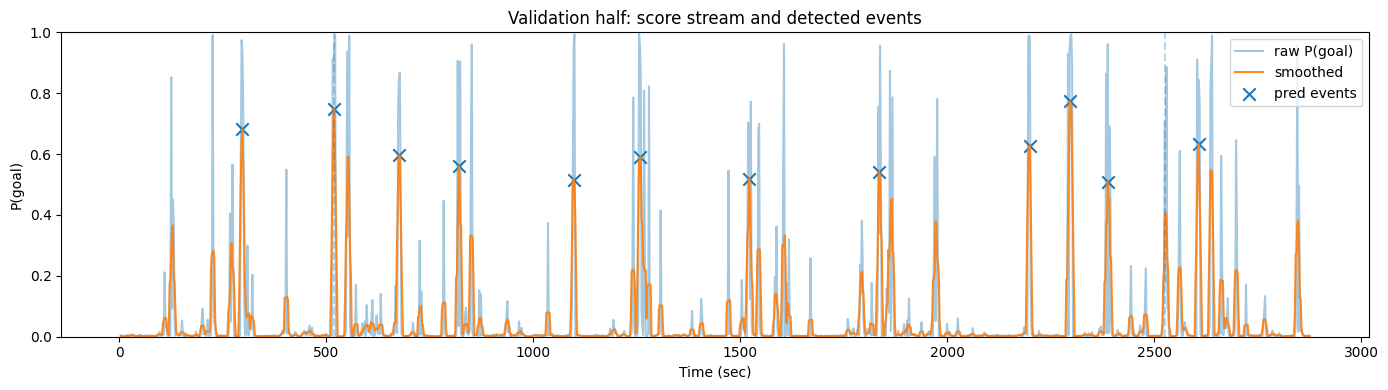

In [18]:
# Cell 11: Inspect predictions on one validation half
import matplotlib.pyplot as plt

example = valid_streams[0]
sm, pred_t, pred_s = detect_goal_events(
    example["centers"],
    example["probs"],
    threshold=best_params["threshold"],
    smooth_k=best_params["smooth_k"],
    nms_sep_sec=best_params["nms_sep"],
)

print("Example:", example["rel_game"], "half", example["half"])
print("GT goals:", example["goal_times"])
print("Pred goals:", [round(float(x), 2) for x in pred_t.tolist()])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(example["centers"], example["probs"], alpha=0.4, label="raw P(goal)")
ax.plot(example["centers"], sm, alpha=0.9, label="smoothed")
if len(pred_t) > 0:
    ax.scatter(pred_t, pred_s, marker="x", s=80, label="pred events")
for gt in example["goal_times"]:
    ax.axvline(gt, linestyle="--", alpha=0.3)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("Time (sec)")
ax.set_ylabel("P(goal)")
ax.set_title("Validation half: score stream and detected events")
ax.legend()
plt.tight_layout()
plt.show()


In [13]:
# Cell 12: Export predicted timestamps for any split (valid/test/train)

def load_split_halves(split_name: str):
    if split_name == "train":
        return train_halves
    if split_name == "valid":
        return valid_halves
    return load_half_metadata(split_name)

def sec_to_mmss(sec: float):
    sec = max(0, int(round(sec)))
    mm = sec // 60
    ss = sec % 60
    return f"{mm:02d}:{ss:02d}"

def export_predictions(split_name: str = "valid"):
    halves = load_split_halves(split_name)
    out_rows = []

    for h in tqdm(halves, desc=f"Exporting {split_name} predictions"):
        centers, probs = score_half(
            model,
            h["video_path"],
            stride_sec=cfg.STRIDE_SEC,
            clip_sec=cfg.CLIP_SEC,
            num_frames=cfg.NUM_FRAMES,
            size=cfg.IMG_SIZE,
        )
        _, pred_t, pred_s = detect_goal_events(
            centers,
            probs,
            threshold=best_params["threshold"],
            smooth_k=best_params["smooth_k"],
            nms_sep_sec=best_params["nms_sep"],
        )

        for t, s in zip(pred_t.tolist(), pred_s.tolist()):
            out_rows.append({
                "split": split_name,
                "rel_game": h["rel_game"],
                "half": h["half"],
                "pred_sec": float(t),
                "pred_mmss": sec_to_mmss(float(t)),
                "confidence": float(s),
                "video_path": h["video_path"],
            })

    out_df = pd.DataFrame(out_rows)
    out_path = os.path.join(cfg.OUT_DIR, f"predicted_goals_{split_name}.csv")
    out_df.to_csv(out_path, index=False)
    print("Saved:", out_path)
    print("Rows:", len(out_df))
    return out_df

pred_valid_df = export_predictions("valid")
display(pred_valid_df.head(20))


Exporting valid predictions:   4%|▍         | 9/200 [2:12:56<47:01:12, 886.24s/it]


KeyboardInterrupt: 

## Notes for quick iteration

- To change tolerance, edit `cfg.TOLERANCE_SEC` in **Cell 1**.
- To reduce false alarms, increase `cfg.NMS_SEPARATIONS` or sweep higher thresholds.
- To increase recall, reduce threshold range lower bound and/or reduce `MIN_NEG_FROM_GOAL_SEC`.
- For faster scans, increase `cfg.STRIDE_SEC` to `1.5` or `2.0`.
- For better recall near goals, increase `cfg.CLIP_SEC` to `10-12`.
